# VAE Result Analysis (Assignment 3 Part 1)

This notebook helps verify whether training/testing succeeded and how well the VAE performed.

It checks:
- expected log artifacts are present
- scalar curves in TensorBoard event files
- best validation and test metrics
- qualitative sample progression across epochs

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings('ignore')

# Edit these only if your paths differ
ASSIGNMENT_ROOT = Path('../').resolve()
LOG_VERSION_DIR = ASSIGNMENT_ROOT / 'vae_logs' / 'lightning_logs' / 'version_58849704'
OUT_FILE = ASSIGNMENT_ROOT / 'vae_58849704.out'
ERR_FILE = ASSIGNMENT_ROOT / 'vae_58849704.err'

print('ASSIGNMENT_ROOT =', ASSIGNMENT_ROOT)
print('LOG_VERSION_DIR =', LOG_VERSION_DIR)

ASSIGNMENT_ROOT = /home/minjih/Deep_Learning/assignment3
LOG_VERSION_DIR = /home/minjih/Deep_Learning/assignment3/vae_logs/lightning_logs/version_58849704


In [2]:
# Basic artifact checks
event_files = sorted(LOG_VERSION_DIR.glob('events.out.tfevents.*'))
sample_files = sorted(LOG_VERSION_DIR.glob('epoch_*_samples.png'))
ckpt_files = sorted((LOG_VERSION_DIR / 'checkpoints').glob('*.ckpt'))

print('Found event files:', len(event_files))
for p in event_files:
    print('  -', p.name)

print('Found sample images:', len(sample_files))
print('Found checkpoints:', len(ckpt_files))
for p in ckpt_files:
    print('  -', p.name)

if not event_files:
    raise FileNotFoundError(f'No TensorBoard event file found in {LOG_VERSION_DIR}')

Found event files: 2
  - events.out.tfevents.1775349064.ng10302.2621246.0
  - events.out.tfevents.1775349521.ng10302.2621246.1
Found sample images: 17
Found checkpoints: 1
  - epoch=75-step=32072.ckpt


In [3]:
# Parse TensorBoard scalars
from tensorboard.backend.event_processing import event_accumulator

def load_scalars(event_paths):
    scalars = {}
    for ev_path in event_paths:
        ea = event_accumulator.EventAccumulator(str(ev_path))
        ea.Reload()
        for tag in ea.Tags().get('scalars', []):
            entries = ea.Scalars(tag)
            if tag not in scalars:
                scalars[tag] = []
            scalars[tag].extend((e.step, e.value) for e in entries)

    # Keep latest value per step and sort by step
    out = {}
    for tag, vals in scalars.items():
        by_step = {}
        for step, value in vals:
            by_step[step] = value
        out[tag] = sorted(by_step.items(), key=lambda x: x[0])
    return out

scalars = load_scalars(event_files)
print('Scalar tags found:')
for k in sorted(scalars):
    print('  -', k)

Scalar tags found:
  - epoch
  - test_bpd
  - train_ELBO
  - train_bpd
  - train_reconstruction_loss
  - train_regularization_loss
  - val_ELBO
  - val_bpd
  - val_reconstruction_loss
  - val_regularization_loss


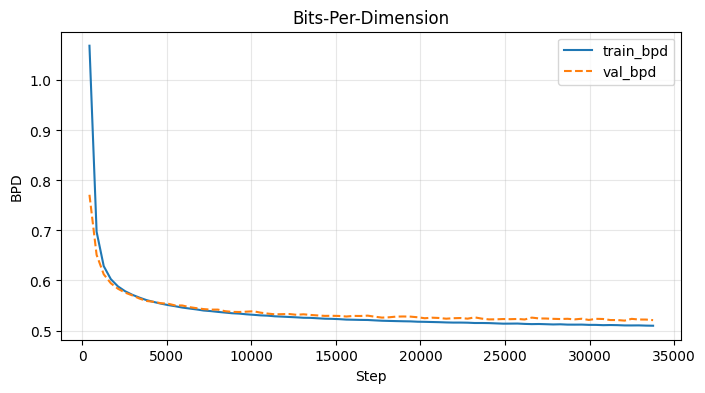

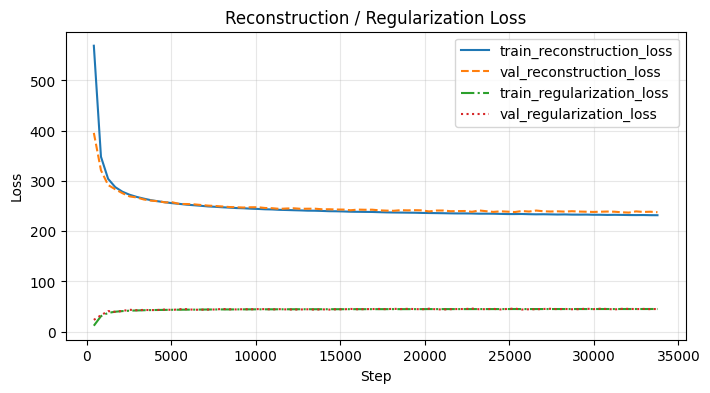

In [5]:
def get_series(tag):
    s = scalars.get(tag, [])
    if not s:
        return [], []
    x = [p[0] for p in s]
    y = [p[1] for p in s]
    return x, y

plt.figure(figsize=(8, 4))
for tag, style in [
    ('train_bpd', '-'),
    ('val_bpd', '--'),
]:
    x, y = get_series(tag)
    if x:
        plt.plot(x, y, style, label=tag)

plt.title('Bits-Per-Dimension')
plt.xlabel('Step')
plt.ylabel('BPD')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
for tag, style in [
    ('train_reconstruction_loss', '-'),
    ('val_reconstruction_loss', '--'),
    ('train_regularization_loss', '-.'),
    ('val_regularization_loss', ':'),
]:
    x, y = get_series(tag)
    if x:
        plt.plot(x, y, style, label=tag)

plt.title('Reconstruction / Regularization Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [6]:
# Numeric summary
summary = {}
for tag in ['train_bpd', 'val_bpd', 'test_bpd', 'train_ELBO', 'val_ELBO']:
    x, y = get_series(tag)
    if y:
        summary[tag] = {
            'last': y[-1],
            'best_min': min(y),
            'best_step': x[y.index(min(y))],
        }

print('Summary metrics:')
for tag, d in summary.items():
    print(f"{tag:>10} | last={d['last']:.6f} | best_min={d['best_min']:.6f} at step={d['best_step']}")

Summary metrics:
 train_bpd | last=0.509594 | best_min=0.509594 at step=33759
   val_bpd | last=0.520749 | best_min=0.519786 at step=32071
  test_bpd | last=0.517877 | best_min=0.517877 at step=33760
train_ELBO | last=276.927429 | best_min=276.927429 at step=33759
  val_ELBO | last=282.989136 | best_min=282.465790 at step=32071


In [7]:
# Parse SLURM stdout/stderr for explicit success signals
test_bpd_from_out = None
max_epoch_reached = False

if OUT_FILE.exists():
    out_text = OUT_FILE.read_text(errors='ignore')
    m = re.search(r'test_bpd\s+([0-9]*\.?[0-9]+)', out_text)
    if m:
        test_bpd_from_out = float(m.group(1))

if ERR_FILE.exists():
    err_text = ERR_FILE.read_text(errors='ignore')
    max_epoch_reached = 'max_epochs=80 reached' in err_text

print('max_epochs reached:', max_epoch_reached)
print('test_bpd (from .out):', test_bpd_from_out)

if test_bpd_from_out is not None and 'test_bpd' in summary:
    print('test_bpd (from event scalars):', summary['test_bpd']['last'])

max_epochs reached: False
test_bpd (from .out): 0.5178766846656799
test_bpd (from event scalars): 0.5178766846656799


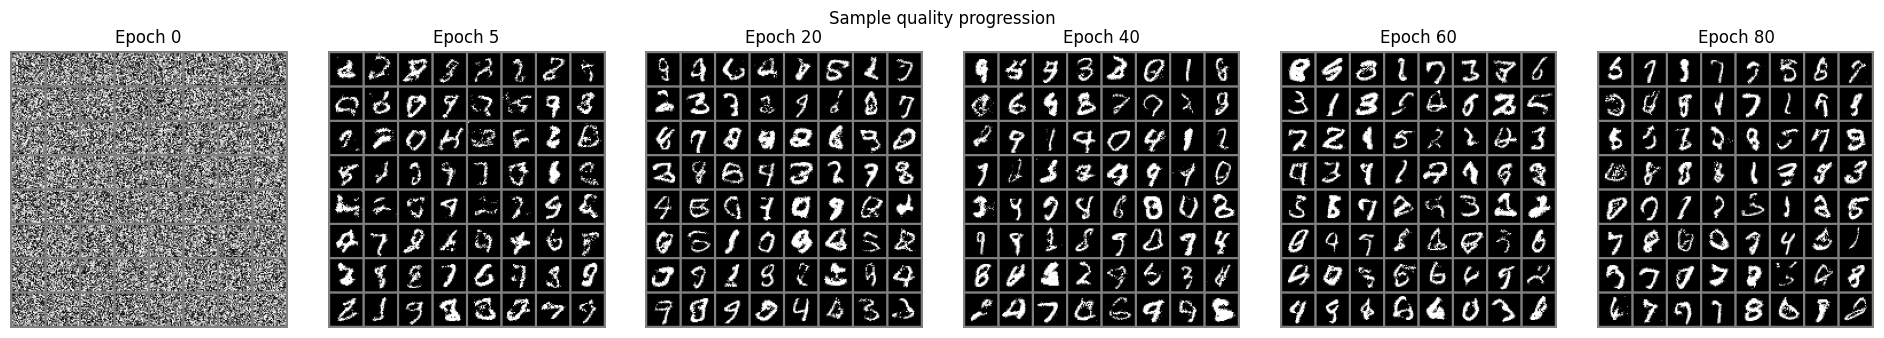

In [8]:
# Visual comparison of generated samples over training
def epoch_from_name(path_obj):
    m = re.search(r'epoch_(\d+)_samples\.png', path_obj.name)
    return int(m.group(1)) if m else -1

sample_files_sorted = sorted(sample_files, key=epoch_from_name)
selected = []
if sample_files_sorted:
    target_epochs = [0, 5, 20, 40, 60, 80]
    by_epoch = {epoch_from_name(p): p for p in sample_files_sorted}
    for e in target_epochs:
        if e in by_epoch:
            selected.append((e, by_epoch[e]))

if not selected:
    print('No sample files available to display.')
else:
    fig, axes = plt.subplots(1, len(selected), figsize=(3.2 * len(selected), 3.4))
    if len(selected) == 1:
        axes = [axes]

    for ax, (epoch, img_path) in zip(axes, selected):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f'Epoch {epoch}')
        ax.axis('off')

    plt.suptitle('Sample quality progression')
    plt.tight_layout()
    plt.show()

## Interpretation Guide

Use this checklist to decide if training/testing was successful:

1. Run completed without crash and reached max epochs (or intended early stop).
2. A best checkpoint was saved under `checkpoints/`.
3. `test_bpd` is present and finite (not NaN/inf).
4. `val_bpd` generally decreases or stabilizes over time.
5. Generated samples become sharper/more digit-like across epochs.

For your current run, a `test_bpd` around `0.5179` was logged in stdout, which is a strong sign the pipeline worked end-to-end.

TensorBoard is still useful for interactive inspection. You can also launch it with:

```bash
cd ../
tensorboard --logdir vae_logs/lightning_logs
```